# Exploratory Data Analysis

## Load Data 

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data import load_ratings, load_movies, clean_ratings

ratings_raw = load_ratings()
movies = load_movies()
ratings = clean_ratings(ratings_raw)

print(movies.shape)
print(ratings.shape)
ratings.head()


(9742, 3)
(100836, 6)


,userId,movieId,rating,timestamp,rated_at,is_positive
0,1,1,4.0,964982703,2000-07-30 18:45:03,True
1,1,3,4.0,964981247,2000-07-30 18:20:47,True
2,1,6,4.0,964982224,2000-07-30 18:37:04,True
3,1,47,5.0,964983815,2000-07-30 19:03:35,True
4,1,50,5.0,964982931,2000-07-30 18:48:51,True


## Dataset Overview

In [2]:
print("Number of unique users:", ratings["userId"].nunique())
print("Number of unique movies:", ratings["movieId"].nunique())

# Calculate the number of ratings per user
ratings_per_user = ratings.groupby("userId")["rating"].count()



Number of unique users: 610
Number of unique movies: 9724


In [3]:
import numpy as np
print("Number of missing values in ratings: ", np.array(ratings.isna()).sum())
print("Number of missing values in movies ", np.array(movies.isna()).sum())

Number of missing values in ratings:  0
Number of missing values in movies  0


In [4]:
date_min = ratings["rated_at"].min()
date_max = ratings["rated_at"].max()
print("Minimum Date: ", date_min)
print("Maximum Date: ", date_max)

Minimum Date:  1996-03-29 18:36:55
Maximum Date:  2018-09-24 14:27:30


## Ratings Distribution

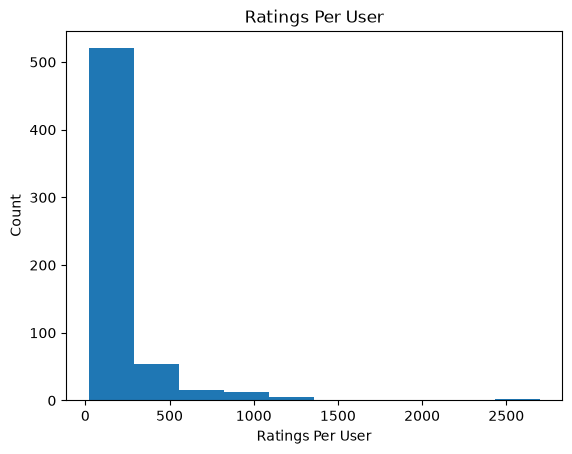

In [5]:
import matplotlib.pyplot as plt

plt.hist(ratings_per_user);
plt.title("Ratings Per User");
plt.xlabel("Ratings Per User")
plt.ylabel("Count");

Ratings per user is right-skewed. Most users have very few ratings, while a few users have a very high amount of ratings. Personalization will likely be easier for these very heavy users, but most likely harder for these lighter users. 

In [6]:
import pandas as pd
rating_counts = pd.DataFrame(ratings["rating"].value_counts().sort_index()).reset_index()
rating_counts

,rating,count
0,0.5,1370
1,1.0,2811
2,1.5,1791
3,2.0,7551
4,2.5,5550
5,3.0,20047
6,3.5,13136
7,4.0,26818
8,4.5,8551
9,5.0,13211


In [7]:
print("Mean rating: ", ratings["rating"].mean())

Mean rating:  3.501556983616962


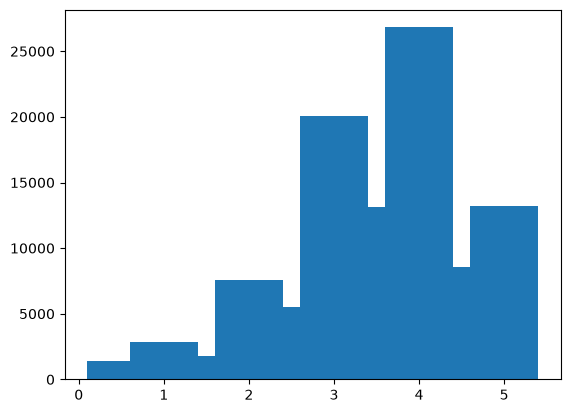

In [8]:
plt.bar(rating_counts["rating"], rating_counts["count"]);

Ratings appear to be left-skewed. Mostly average to positive ratings with only a few really bad ratings. 

## Movie Popularity

In [9]:
ratings_with_titles = ratings.merge(
    movies,
    on="movieId",
    how="left"
)


In [10]:
ratings_with_titles

,userId,movieId,rating,timestamp,rated_at,is_positive,title,genres
0,1,1,4.0,964982703,2000-07-30 18:45:03,True,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,2000-07-30 18:20:47,True,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,2000-07-30 18:37:04,True,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,2000-07-30 19:03:35,True,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,2000-07-30 18:48:51,True,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...,...,...
100831,610,166534,4.0,1493848402,2017-05-03 21:53:22,True,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,2017-05-03 22:21:31,True,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,1494273047,2017-05-08 19:50:47,True,Get Out (2017),Horror
100834,610,168252,5.0,1493846352,2017-05-03 21:19:12,True,Logan (2017),Action|Sci-Fi


In [11]:
movie_rated = ratings_with_titles.groupby("movieId").size().reset_index().rename(columns={0: "count"})
movie_rated = movie_rated.copy().merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)
movie_rated.sort_values(by="count", ascending=False).head(20)

,movieId,count,title
314,356,329,Forrest Gump (1994)
277,318,317,"Shawshank Redemption, The (1994)"
257,296,307,Pulp Fiction (1994)
510,593,279,"Silence of the Lambs, The (1991)"
1938,2571,278,"Matrix, The (1999)"
224,260,251,Star Wars: Episode IV - A New Hope (1977)
418,480,238,Jurassic Park (1993)
97,110,237,Braveheart (1995)
507,589,224,Terminator 2: Judgment Day (1991)
461,527,220,Schindler's List (1993)


In [12]:
movie_rated["count"].describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: count, dtype: float64

* Older movies tend to dominate the most popular
* Most movies have very few ratings with a small number of movies with a lot of ratings

## Possible User/Movie Pairs

In [13]:
movie_user_pairs = ratings["userId"].nunique() * movies["movieId"].nunique()
print("Number of Possible Movie, User Pairs: ", movie_user_pairs)
observed_ratings = len(ratings)
print("Observed ratings: ", observed_ratings)

sparsity = 1 - observed_ratings / movie_user_pairs
print("Sparsity: ", sparsity)

Number of Possible Movie, User Pairs:  5942620
Observed ratings:  100836
Sparsity:  0.9830317267467884


Most user-movie preferences are unobserved. Hence, recommendation can be a challenge

## Genre Distribution

In [14]:
genres = movies["genres"].str.split("|").explode()
genres.value_counts()

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

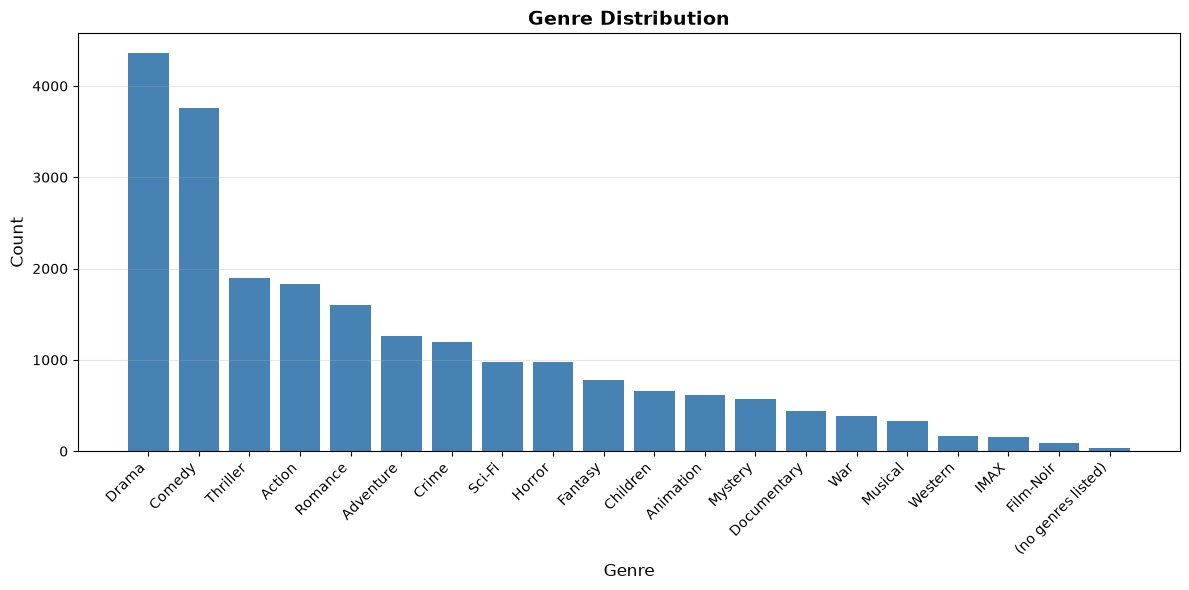

In [15]:
genres = pd.DataFrame(genres)
genre_count = genres.groupby("genres").size().reset_index().rename(columns={0: "count"})
genre_count = genre_count.sort_values("count", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(genre_count["genres"], genre_count["count"], color="steelblue")
plt.title("Genre Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

Some genres are more popular than others and can be an easy baseline for a recommendation system

## Time Trends

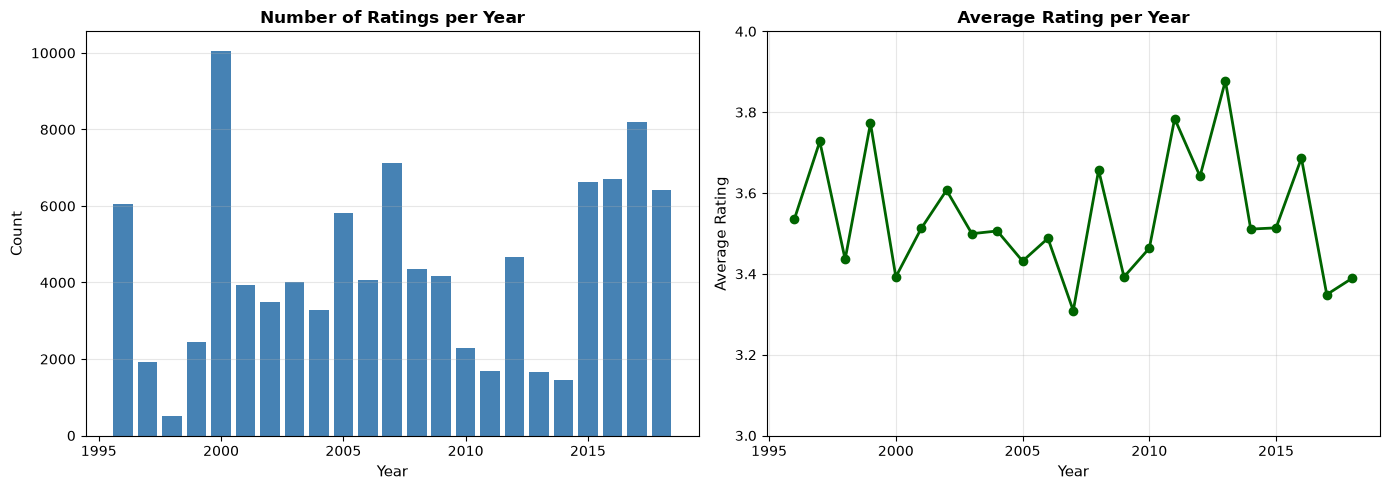

In [16]:
# Extract year from rated_at and create time-based analysis
ratings["year"] = ratings["rated_at"].dt.year

# Ratings per year
ratings_per_year = ratings.groupby("year").size().reset_index(name="count")

# Average rating by year
avg_rating_per_year = ratings.groupby("year")["rating"].mean().reset_index(name="avg_rating")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ratings per year
axes[0].bar(ratings_per_year["year"], ratings_per_year["count"], color="steelblue")
axes[0].set_title("Number of Ratings per Year", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Year", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Average rating by year
axes[1].plot(avg_rating_per_year["year"], avg_rating_per_year["avg_rating"], marker="o", linewidth=2, markersize=6, color="darkgreen")
axes[1].set_title("Average Rating per Year", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Year", fontsize=11)
axes[1].set_ylabel("Average Rating", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([3.0, 4.0])

plt.tight_layout()
plt.show()

Activity and ratings change over the years, but neither exhibit a monotonic trend. In fact, the number of ratings and average rating are pretty sporadic over the years. 

## Train/test split check

In [17]:
from src.data import temporal_train_test_split

train, test = temporal_train_test_split(ratings)

print(train.shape)
print(test.shape)

(80896, 7)
(19940, 7)


In [19]:
print("Train set date range: ", train["rated_at"].min(), " to ", train["rated_at"].max())
print("Test set date range: ", test["rated_at"].min(), " to ", test["rated_at"].max())

# Additional validation checks
print("\n--- Temporal Split Validation ---")

# 1. Check for no overlap in dates
train_max = train["rated_at"].max()
test_min = test["rated_at"].min()
print(f"Train max date: {train_max}")
print(f"Test min date: {test_min}")
print(f"No date overlap: {train_max < test_min}")

# 2. Check split ratio
total_ratings = len(ratings)
train_ratio = len(train) / total_ratings
test_ratio = len(test) / total_ratings
print(f"\nTrain ratio: {train_ratio:.2%}")
print(f"Test ratio: {test_ratio:.2%}")

# 3. Check unique users/movies in each set
print(f"\nTrain - Unique users: {train['userId'].nunique()}, Unique movies: {train['movieId'].nunique()}")
print(f"Test - Unique users: {test['userId'].nunique()}, Unique movies: {test['movieId'].nunique()}")

# 4. Check for cold start problem (users only in test set)
train_users = set(train["userId"].unique())
test_users = set(test["userId"].unique())
cold_start_users = test_users - train_users
print(f"\nUsers only in test set (cold start): {len(cold_start_users)}")

# 5. Check for new movies in test set
train_movies = set(train["movieId"].unique())
test_movies = set(test["movieId"].unique())
cold_start_movies = test_movies - train_movies
print(f"Movies only in test set (cold start): {len(cold_start_movies)}")

# 6. USER-LEVEL TEMPORAL CHECK: Verify users don't overlap between train and test
print("\n--- User-Level Temporal Split ---")
users_in_both = train_users & test_users
print(f"Users appearing in both train and test: {len(users_in_both)}")

if len(users_in_both) > 0:
    print("\nChecking temporal consistency for overlapping users:")
    user_overlap_issues = []
    for user in list(users_in_both)[:10]:  # Check first 10 as sample
        train_user_max = train[train["userId"] == user]["rated_at"].max()
        test_user_min = test[test["userId"] == user]["rated_at"].min()
        is_valid = train_user_max < test_user_min
        if not is_valid:
            user_overlap_issues.append((user, train_user_max, test_user_min))
        print(f"  User {user}: Train max={train_user_max}, Test min={test_user_min}, Valid={is_valid}")
    
    if user_overlap_issues:
        print(f"\n⚠️  Found {len(user_overlap_issues)} users with temporal overlap!")
    else:
        print("\n✓ All sampled overlapping users maintain temporal order.")
else:
    print("✓ No users appear in both train and test (clean user-level split)")

Train set date range:  1996-03-29 18:36:55  to  2018-09-17 04:25:01
Test set date range:  1996-03-29 18:36:56  to  2018-09-24 14:27:30

--- Temporal Split Validation ---
Train max date: 2018-09-17 04:25:01
Test min date: 1996-03-29 18:36:56
No date overlap: False

Train ratio: 80.23%
Test ratio: 19.77%

Train - Unique users: 610, Unique movies: 8246
Test - Unique users: 610, Unique movies: 6243

Users only in test set (cold start): 0
Movies only in test set (cold start): 1478

--- User-Level Temporal Split ---
Users appearing in both train and test: 610

Checking temporal consistency for overlapping users:
  User 1: Train max=2000-07-30 18:54:42, Test min=2000-07-30 18:56:33, Valid=True
  User 2: Train max=2015-10-24 19:32:52, Test min=2015-10-24 19:33:09, Valid=True
  User 3: Train max=2011-05-27 02:43:24, Test min=2011-05-27 02:43:36, Valid=True
  User 4: Train max=2001-04-09 20:47:18, Test min=2001-04-09 20:47:34, Valid=True
  User 5: Train max=1996-11-08 06:41:32, Test min=1996-11-

In [ ]:
# Deep dive into the overlapping user with same timestamp
print("\n--- Detailed Analysis of User with Temporal Overlap ---")

# Find the problematic user(s) where timestamps are exactly equal
if user_overlap_issues:
    for user, train_max, test_min in user_overlap_issues:
        print(f"\nUser {user}:")
        print(f"  Overlapping timestamp: {train_max} (should be {test_min})")
        
        # Get all ratings from this user at the conflicting timestamp
        user_ratings_at_conflict = ratings[
            (ratings["userId"] == user) & 
            (ratings["rated_at"] == train_max)
        ]
        
        print(f"  Total ratings at this timestamp: {len(user_ratings_at_conflict)}")
        print(f"  In train: {len(train[(train['userId'] == user) & (train['rated_at'] == train_max)])}")
        print(f"  In test: {len(test[(test['userId'] == user) & (test['rated_at'] == test_min)])}")
        print(f"  Movies rated: {user_ratings_at_conflict['movieId'].tolist()}")
else:
    # If no issues from the previous check, let's see if any users have same timestamp ratings
    print("No temporal ordering issues found in sampled users.")
    print("\nChecking if ANY users have multiple ratings at same timestamp across train/test:")
    
    for user in list(users_in_both)[:20]:  # Sample first 20 overlapping users
        train_user_data = train[train["userId"] == user].sort_values("rated_at")
        test_user_data = test[test["userId"] == user].sort_values("rated_at")
        
        if len(train_user_data) > 0 and len(test_user_data) > 0:
            train_last_time = train_user_data["rated_at"].max()
            test_first_time = test_user_data["rated_at"].min()
            
            if train_last_time == test_first_time:
                print(f"\nUser {user} has ratings at exact same timestamp: {train_last_time}")
                print(f"  Train ratings at this time: {len(train[(train['userId'] == user) & (train['rated_at'] == train_last_time)])}")
                print(f"  Test ratings at this time: {len(test[(test['userId'] == user) & (test['rated_at'] == test_first_time)])}")